# 01 - Frame Extraction

**Pipeline stage:** Dataset Preprocessing and Environment Setup

Extracts frames from CityFlow camera videos in `data/raw` and organises them into `data/interim/frames/<scene>/<camera>/

CityFlow raw layout:
```
data/raw/
    train/ or test/
        <scene_id>/          e.g. S01
            <camera_id>/     e.g. c001
                vdo.avi
                roi.jpg
                calibration.txt
                det/ gt/ mtsc/ segm/   (not used by this notebook)
```

In [5]:
import csv
from pathlib import Path

import numpy as np
import cv2

In [6]:
raw_dir = Path("../data/raw")
out_dir = Path("../data/frames")
sample_rate = 1  # sample every nth frame
apply_roi_mask = True  # apply ROI mask to frames

In [7]:
def find_camera_dirs(raw_dir: Path):
    """Locate every folder under raw_dir that contains a video file."""
    camera_dirs = []
    for path in raw_dir.rglob("*"):
        if path.is_dir():
            videos = list(path.glob("*.avi")) + list(path.glob("*.mp4"))
            if videos:
                camera_dirs.append((path, videos[0]))
    return camera_dirs

In [8]:
def load_roi_mask(camera_dir: Path, frame_shape):
    """Load roi.jpg for a camera and return a binary mask matching frame_shape, or None if absent."""
    roi_path = camera_dir / "roi.jpg"
    if not roi_path.exists():
        return None
    roi = cv2.imread(str(roi_path), cv2.IMREAD_GRAYSCALE)
    if roi is None:
        return None
    if roi.shape[:2] != frame_shape[:2]:
        roi = cv2.resize(roi, (frame_shape[1], frame_shape[0]))
    _, mask = cv2.threshold(roi, 127, 255, cv2.THRESH_BINARY)
    return mask

In [9]:
def extract_frames(video_path: Path, camera_dir: Path, out_dir: Path, sample_fps: float,
                    writer, scene_id: str, camera_id: str, apply_roi: bool):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  [skip] could not open {video_path}")
        return 0

    source_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    frame_interval = max(int(round(source_fps / sample_fps)), 1)

    out_dir.mkdir(parents=True, exist_ok=True)

    roi_mask = None
    frame_idx = 0
    saved_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % frame_interval == 0:
            if apply_roi:
                if roi_mask is None:
                    roi_mask = load_roi_mask(camera_dir, frame.shape)
                if roi_mask is not None:
                    frame = cv2.bitwise_and(frame, frame, mask=roi_mask)

            timestamp_sec = frame_idx / source_fps
            filename = f"frame_{saved_idx:06d}.jpg"
            cv2.imwrite(str(out_dir / filename), frame)
            writer.writerow({
                "scene_id": scene_id,
                "camera_id": camera_id,
                "frame_file": filename,
                "source_frame_idx": frame_idx,
                "timestamp_sec": round(timestamp_sec, 3),
                "roi_applied": roi_mask is not None,
            })
            saved_idx += 1
        frame_idx += 1

    cap.release()
    return saved_idx

In [10]:
out_dir.mkdir(parents=True, exist_ok=True)

camera_dirs = find_camera_dirs(raw_dir)
if not camera_dirs:
    raise FileNotFoundError(f"No video files found under {raw_dir}. Check the folder structure.")

print(f"Found {len(camera_dirs)} camera video(s) under {raw_dir}")

metadata_path = out_dir / "frame_metadata.csv"
with open(metadata_path, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["scene_id", "camera_id", "frame_file", "source_frame_idx", "timestamp_sec", "roi_applied"],
    )
    writer.writeheader()

    total_frames = 0
    for camera_path, video_path in camera_dirs:
        camera_id = camera_path.name
        scene_id = camera_path.parent.name
        frame_out_dir = out_dir / scene_id / camera_id

        print(f"Processing {scene_id}/{camera_id} ({video_path.name})...")
        n_saved = extract_frames(
            video_path, camera_path, frame_out_dir, sample_rate, writer, scene_id, camera_id, apply_roi_mask
        )
        print(f"  saved {n_saved} frames -> {frame_out_dir}")
        total_frames += n_saved

print(f"\nDone. {total_frames} frames extracted in total.")
print(f"Metadata written to {metadata_path}")

Found 65 camera video(s) under ..\data\raw
Processing S02/c006 (vdo.avi)...
  saved 211 frames -> ..\data\frames\S02\c006
Processing S02/c007 (vdo.avi)...
  saved 197 frames -> ..\data\frames\S02\c007
Processing S02/c008 (vdo.avi)...
  saved 193 frames -> ..\data\frames\S02\c008
Processing S02/c009 (vdo.avi)...
  saved 211 frames -> ..\data\frames\S02\c009
Processing S05/c010 (vdo.avi)...
  saved 408 frames -> ..\data\frames\S05\c010
Processing S05/c016 (vdo.avi)...
  saved 394 frames -> ..\data\frames\S05\c016
Processing S05/c017 (vdo.avi)...
  saved 388 frames -> ..\data\frames\S05\c017
Processing S05/c018 (vdo.avi)...
  saved 385 frames -> ..\data\frames\S05\c018
Processing S05/c019 (vdo.avi)...
  saved 390 frames -> ..\data\frames\S05\c019
Processing S05/c020 (vdo.avi)...
  saved 398 frames -> ..\data\frames\S05\c020
Processing S05/c021 (vdo.avi)...
  saved 401 frames -> ..\data\frames\S05\c021
Processing S05/c022 (vdo.avi)...
  saved 428 frames -> ..\data\frames\S05\c022
Processin

## Sanity Check 
previewing one extracted frame to confirm the ROI mask looks correct.

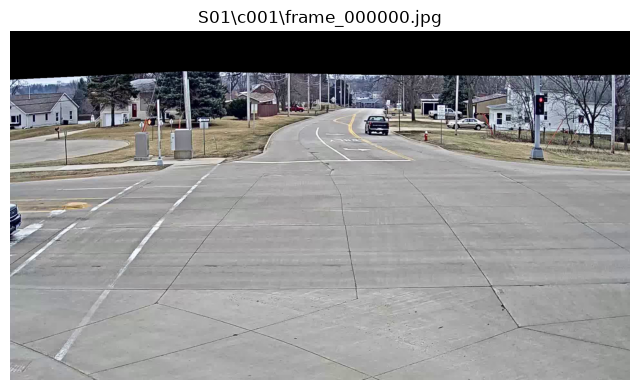

In [17]:
import matplotlib.pyplot as plt

sample_scene_dir = next(p for p in out_dir.iterdir() if p.is_dir())
sample_camera_dir = next(p for p in sample_scene_dir.iterdir() if p.is_dir())
sample_frame = next(sample_camera_dir.glob("*.jpg"))

img = cv2.cvtColor(cv2.imread(str(sample_frame)), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(sample_frame.relative_to(out_dir))
plt.axis("off")
plt.show()